In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Topic Analysis and Topic-Specific Text Extraction

## Overview

This notebook implements the topic modelling pipeline used in the project to identify sentences related to predefined policy dimensions in political manifestos.

The main objective is to extract sentences concerning **Foreign Affairs** from political manifestos. These sentences are subsequently used as input for the sentiment analysis pipeline.

The topic identification step relies on a **seeded Latent Dirichlet Allocation (LLDA)** approach. Unlike an unsupervised topic model, where topics are discovered without predefined semantic categories, LLDA uses manually defined seed words to guide the model towards policy dimensions of interest.

### Pipeline

The complete workflow is:

```text
Raw manifesto files
        │
        ▼
Manifesto corpus construction
        │
        ▼
Text preprocessing
        │
        ▼
Definition of policy categories
        │
        ▼
Definition of seed words
        │
        ▼
Seeded LDA (LLDA)
        │
        ├──────────────► Topic quality evaluation
        │
        ▼
Topic-specific sentence extraction
        │
        ▼
Foreign Affairs corpus
        │
        ▼
CSV file
        │
        ▼
Sentiment analysis
```

The notebook therefore acts as an intermediate stage between the raw manifesto corpus and the sentiment analysis.

## Why use a seeded topic model?

The research is not interested in discovering arbitrary topics from the manifestos. Instead, it focuses on a predefined set of policy dimensions:

* Social Affairs
* Culture
* Education
* Economy
* Justice
* Internal Affairs
* Environment
* Foreign Affairs

Each policy dimension is associated with a set of **seed words**. These words provide semantic information to the LLDA model and help it identify sentences belonging to the corresponding policy domain.

The output of this stage is therefore not a sentiment score. It is a **topic-specific text corpus** that can be analysed in the next stage of the pipeline.


## 1. Imports

The analysis relies on three groups of components:

* `manifesto_preprocessing`: functions used to load and structure the manifesto corpus;
* `llda_functions`: functions implementing the seeded topic modelling and topic-specific text extraction;
* `seedwords`: utilities for generating or exploring candidate seed words.

spaCy is used for linguistic preprocessing.


In [2]:
from topic_analysis import manifesto_preprocessing as mp
from topic_analysis import llda_functions as llda
from topic_analysis import seedwords as sw 
import spacy

## 2. Loading the USA manifesto corpus

The first corpus analysed in this notebook consists of US political manifestos.

The raw files are stored in:

```text
data/raw/manifestos/usa/
```

Each filename contains a party prefix and an election year:

```text
dem_2024.csv
rep_2024.csv
```

The prefix is mapped to the full party name:

* `dem` → Democratic Party
* `rep` → Republican Party

This mapping is passed to `structure_manifestos()`, which loads the individual manifesto files and converts them into a structured dataframe suitable for the topic modelling pipeline.


In [3]:
usa_manifesto_dir="../data/raw/manifestos/usa"
usa_party_mapper = {"dem": "Democratic Party", "rep": "Republican Party"}

## 3. Text preprocessing

The manifesto corpus is processed using the English `spaCy` model `en_core_web_sm`.

The maximum document length is increased because some manifesto documents are substantially longer than spaCy's default limit.

The resulting `usa_manifestos` dataframe is the main input to the topic modelling stage.


In [4]:
NLP = spacy.load("en_core_web_sm")
NLP.max_length = 2000000
usa_manifestos = mp.structure_manifestos(usa_manifesto_dir, usa_party_mapper)

## 4. Policy categories

The topic model is constrained to eight policy dimensions:

```text
Social Affairs
Culture
Education
Economy
Justice
Internal Affairs
Environment
Foreign Affairs
```

These categories correspond to the substantive policy dimensions investigated in the research.

The model will use these categories as its predefined topics rather than discovering an arbitrary number of topics.


In [5]:
SEEDS = [42] # , 22, 33, 42, 55
CATEGORIES = ["Social_Affairs", "Culture", "Education", "Economy", "Justice", "Internal_Affairs", "Environment", "Foreign_Affairs"] # Target dimensions

## 5. Seed words

### What are seed words?

Seed words are words that provide semantic guidance to the topic model.

For example, words such as:

```text
military
defense
war
international
foreign
treaty
security
```

are indicative of the **Foreign Affairs** domain.

The seed dictionary therefore associates a list of words with each policy category.

### How were the seed words obtained?

The project provides a utility function, `generate_seed_words()`, which can be used to inspect frequent or characteristic words in the corpus.

A typical workflow is:

1. generate candidate words from the manifesto corpus;
2. inspect the candidate vocabulary;
3. assign relevant words to the predefined policy categories;
4. use the resulting dictionary as input to LLDA.

The final assignment of words to categories is therefore partly **research-design driven** rather than being entirely determined by the statistical model.

In this project, large language models can also be used to assist with the semantic classification of candidate words. The resulting seed dictionary should nevertheless be regarded as a methodological input to the analysis and should be documented and justified separately. 

In order to define the seed words, you should run the `sw.generate_seed_words()`. This will give you the top words of the document.
The next task is to assign these words to our categories. 
This could be done (and actually have been done in this project) by using an LLM (ChatGPT, Claude, etc.)


### Important distinction

`SEEDS` and `seed_words_dict` refer to two different concepts.

* `SEEDS = [42]` controls the random initialization of the statistical model.
* `seed_words_dict` contains the vocabulary used to define the policy topics.

The two should not be confused.

In [ ]:
#sw.generate_seed_words(usa_manifestos, NLP, seed = 42, k = 8, top_n_words = 100)

In [7]:
usa_words_dict = {
	"Social_Affairs": [
        "family", "worker", "work", "wage", "income", "benefit", "housing", "home", "community", "poverty", "employment", "job", "labor", "child", "woman", "disability", "veteran",
		"health", "care", "medical", "insurance", "coverage", "patient", "mental", "treatment", "disease", "affordable", "service", "access", "quality", "help"],

	"Culture": [
		"america", "american", "americans", "nation", "party", "believe", "great", "freedom", "free", "value", "life", "society", "responsibility", "man", "promise", "platform", "leadership",
        "future", "century", "identity", "religious", "civil", "rights", "equal", "discrimination"
	],

	"Education": [
		"education", "school", "student", "college", "teacher", "parent", "training", "funding", "research", "quality",
		"public", "access", "opportunity", "program"],

	"Economy": [
		"tax", "business", "market", "economy", "economic", "growth", "budget", "spending", "rate", "pay", "income", "billion", "million", "percent", "dollar", "price",
		"inflation", "credit", "investment", "create", "cost", "small", "financial", "private", "industry", "trade", "export", "production", "supply", "farm", "farmer", "agriculture", "rural"
	],

	"Justice": [
        "law", "crime", "criminal", "court", "justice", "enforcement", "legal", "constitutional", "constitution", "amendment", "rule", "act", "legislation", "protect",
		"protection", "enforce", "violence", "drug", "rights", "civil", "equal", "discrimination"
	],

	"Internal_Affairs": [
		"government", "federal", "state", "local", "congress", "president", "administration", "agency", "policy", "program", "public", "reform", "regulation", "citizen","vote",
        "democratic", "republican", "democrats", "republicans", "immigration", "city", "level", "control", "assistance", "fund", "system"
	],

	"Environment": [
		"energy", "clean", "water", "environmental", "environment", "climate", "natural", "resource", "land", "oil", "science", "technology", "infrastructure", "protect",
		"production", "food", "agriculture", "rural"
	],

	"Foreign_Affairs": [
		"military", "nuclear", "defense", "force", "security", "weapon", "war", "threat", "soviet", "world", "international", "attack", "u.s.", "united", "states",
		"intelligence", "strategic", "armed", "missile", "ally", "iraq", "treaty", "terrorism", "terrorist", "union", "agreement", "combat", "troop", "personnel", "strategy",
		"foreign", "peace", "democracy", "israel", "human", "region", "interest", "africa", "china", "east", "europe", "middle", "relationship", "relation", "cooperation", 
        "nations", "south", "asia", "global", "partner"
	]
}

## 6. Seeded LDA / LLDA

The topic model used in this project is a **seeded Latent Dirichlet Allocation (LLDA)** model.

Standard LDA attempts to discover latent topics from the vocabulary of a collection of documents. LLDA adds prior information by associating predefined seed words with specific topics.

In this project, the predefined topics correspond to policy dimensions such as `Economy`, `Environment` or `Foreign_Affairs`.

Conceptually:

```text
Manifesto sentences
        │
        ▼
Text preprocessing
        │
        ▼
Words associated with predefined seed categories
        │
        ▼
LLDA
        │
        ▼
Topic probabilities / topic assignments
        │
        ▼
Identification of sentences associated with a policy dimension
```

The model is therefore used as a **guided text classification mechanism at the topic level**.

The final objective is not simply to estimate the prevalence of topics, but to identify the sentences that are most relevant to a particular policy domain.

## 7. Evaluating topic quality

Before extracting topic-specific sentences, the quality of the topic model can be evaluated using two complementary measures:

* **NPMI (Normalized Pointwise Mutual Information)** evaluates topic coherence. It measures how frequently the words associated with a topic tend to occur together.
* **Topic drift** measures how much the estimated topic representation changes across model runs or experimental settings.

Because topic models involve stochastic estimation, repeating the model with different random seeds can help assess the stability of the results.

The evaluation is performed separately for the Democratic and Republican Party corpora.

The resulting plots provide a diagnostic of whether the predefined topic structure produces coherent and stable results.



=== Starting LLDA Pipeline for: ['Democratic Party'] ===
  Running LLDA with seed 42...


C:\Users\gbedo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tomotopy\models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


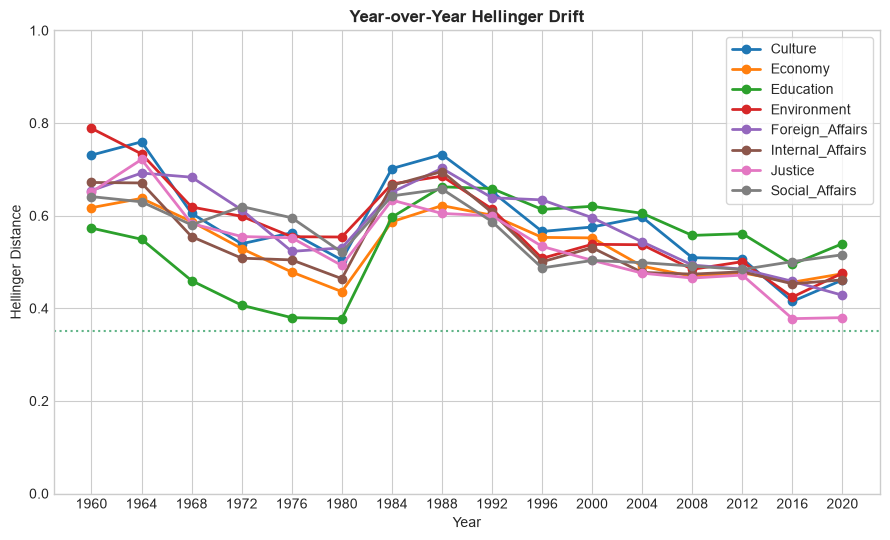

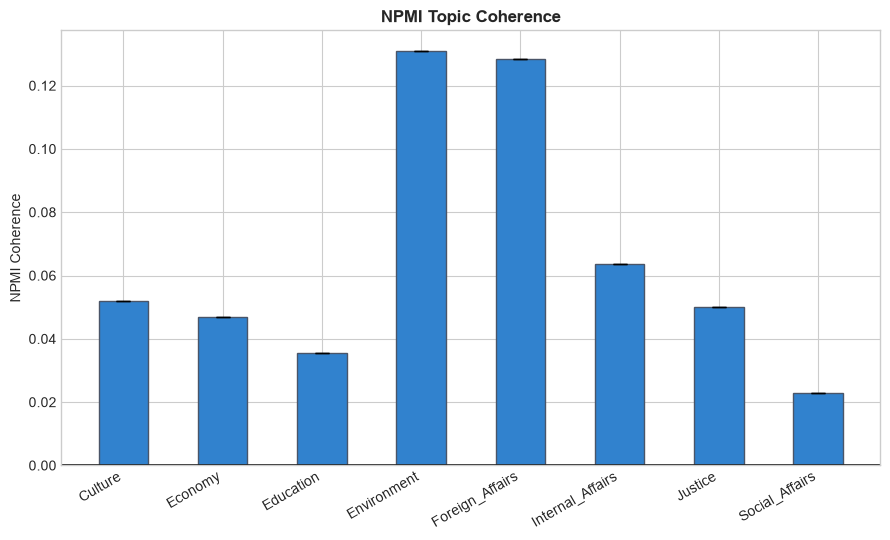

In [8]:
drift_summary, npmi_summary = llda.evaluate_results(manifestos_dataframe=usa_manifestos, nlp=NLP, categories=CATEGORIES, seeds=SEEDS, seed_words_dict=usa_words_dict, parties=["Democratic Party"])
llda.plot_drift_with_confidence_bounds(drift_summary)
llda.plot_npmi_with_confidence_bounds(npmi_summary)

In [ ]:
drift_summary, npmi_summary = llda.evaluate_results(manifestos_dataframe=usa_manifestos, nlp=NLP, categories=CATEGORIES, seeds=SEEDS, seed_words_dict=usa_words_dict, parties=["Republican Party"])
llda.plot_drift_with_confidence_bounds(drift_summary)
llda.plot_npmi_with_confidence_bounds(npmi_summary)

In [ ]:
results = llda.comparison_results(manifestos_dataframe=usa_manifestos, nlp=NLP, categories=CATEGORIES, seeds=SEEDS, seed_words_dict=usa_words_dict, party_a = "Democratic Party", party_b = "Republican Party")

In [ ]:
llda.plot_comparison(results, topic="Foreign_Affairs")

## 8. Extracting Foreign Affairs sentences

Once the topic model has been estimated, the next step is to extract the manifesto sentences associated with the `Foreign_Affairs` topic.

The function `extract_topic_sentences_by_party()` applies the LLDA pipeline to the complete manifesto corpus and returns the sentences identified as belonging to the selected topic.

In this notebook:

```python
topic="Foreign_Affairs"
```

is used because Foreign Affairs is the policy dimension required for the subsequent sentiment analysis.

The extraction is performed at the **sentence level**, while preserving the party structure of the corpus.

The resulting dataframe is therefore an intermediate dataset containing Foreign Affairs-related manifesto text for each political party.

It is saved to:

```text
data/intermediate/foreign_affairs/usa_foreignAffairs_text.csv
```

This file is subsequently consumed by the sentiment analysis pipeline.


In [ ]:
foreignAffairs_data = llda.extract_topic_sentences_by_party(manifestos_dataframe=usa_manifestos, nlp=NLP, categories=CATEGORIES, seed_words_dict=usa_words_dict, topic="Foreign_Affairs", seed=42)

In [ ]:
foreignAffairs_data.to_csv("../data/intermediate/foreign_affairs/usa_foreignAffairs_text.csv")

# Australia

The previous pipeline can be exactly replicated for any country provided that the manifestos are available.
We must note that we restrained ourselves to English-speaking countries in this work.

In [ ]:
# manifesto_dir="../data/raw/manifestos/australia"

# party_prefix_mapper = {
#  'alp': 'Australian Labor Party',
#  'dlp': 'Democratic Labor Party',
#  'lpa': 'Liberal Party of Australia',
#  'npa': 'National Party of Australia',
#  'ad': 'Australian Democrats',
#  'ag': 'Australian Greens',
#  'lnpq': 'Liberal National Party of Queensland',
#  'kap': "Katter's Australian Party",
#  'pup': 'Palmer United Party',
#  'ca': 'Centre Alliance',
#  "clp":  "Country Liberal Party"
#  }


In [ ]:
# NLP = spacy.load("en_core_web_sm")
# NLP.max_length = 2000000

# usa_manifestos = mp.structure_manifestos(manifesto_dir, party_prefix_mapper)

# SEEDS = [11] # , 22, 33, 42, 55

# CATEGORIES = ["Social_Affairs", "Culture", "Education", "Economy", "Justice", "Internal_Affairs", "Environment", "Foreign_Affairs"] # Target dimensions

In [ ]:
#sw.generate_seed_words(usa_manifestos, NLP, seed = 42, k = 8, top_n_words = 100)

In [ ]:
# usa_words_dict = CATEGORIES_MAPPING = {
#     "Social_Affairs": [
#         "family", "pensioner", "pension", "allowance", "retirement", 
#         "parent", "household", "earner", "woman", "women", "child", 
#         "community", "social", "domestic", "violence", "abuse", "drug", 
#         "multicultural", "anti", "discrimination", "humanitarian", 
#         "refugee", "gender", "victim", "indigenous", "disability", 
#         "aboriginal", "youth", "ndis", "strait", "torres", "islander", 
#         "remote", "care", "mental", "aged", "veteran", "suicide", "parental"
#     ],
#     "Culture": [
#         "sport", "multicultural", "tourist", "visitor", "park"
#     ],
#     "Education": [
#         "school", "education", "student", "skill", "training", 
#         "university", "teacher", "apprentice", "apprenticeship", 
#         "tafe", "career", "study", "child", "early"
#     ],
#     "Economy": [
#         "business", "tax", "small", "cost", "income", "low", 
#         "increase", "million", "billion", "rate", "housing", "pay", 
#         "scheme", "payment", "benefit", "guarantee", "relief", 
#         "superannuation", "asset", "company", "cut", "buy", "loan", 
#         "financial", "investment", "buyer", "price", "medium", "deposit", 
#         "ownership", "purchase", "save", "energy", "incentive", "affordable", 
#         "market", "average", "living", "super", "worker", "budget", 
#         "invest", "saving", "capital", "employee", "employ", "economy", 
#         "job", "economic", "taxis", "growth", "policy", "unemployment", 
#         "grow", "money", "debt", "spending", "wage", "productivity", 
#         "infrastructure", "gdp", "industry", "export", "trade", 
#         "employment", "workforce", "employer", "skilled", "participation"
#     ],
#     "Justice": [
#         "law", "crime", "criminal", "act", "anti", "discrimination", 
#         "police", "protection", "right", "legal", "victim", "enforcement", 
#         "court", "commission"
#     ],
#     "Internal_Affairs": [
#         "online", "security", "safety", "safe", "cyber", "border", 
#         "visa", "esafety", "illegal", "digital", "terrorist", 
#         "terrorism", "counter", "road", "infrastructure", "project", 
#         "transport", "rail", "highway", "mobile", "network", "freight", 
#         "airport", "construction", "nbn", "vehicle", "vessel"
#     ],
#     "Environment": [
#         "water", "environment", "reef", "resource", "agriculture", 
#         "climate", "emission", "gas", "environmental", "drought", 
#         "agricultural", "food", "clean", "farm", "renewable", "science", 
#         "forestry", "marine", "coal", "forest", "land", "waste", 
#         "animal", "barrier", "carbon", "natural"
#     ],
#     "Foreign_Affairs": [
#         "world", "pacific", "foreign", "humanitarian", "refugee", 
#         "partner", "threat", "international", "global", "defence", 
#         "aid", "trade", "united", "states"
#     ]
# }